In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler


In [32]:

# 1. Загрузка данных
data = sns.load_dataset('titanic')


In [33]:
# 2. Расширенный EDA
print("="*50)
print("Первые 5 строк данных:")
print(data.head())

print("\n" + "="*50)
print("Информация о данных:")
print(data.info())

print("\n" + "="*50)
print("Пропущенные значения:")
print(data.isnull().sum())


Первые 5 строк данных:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------

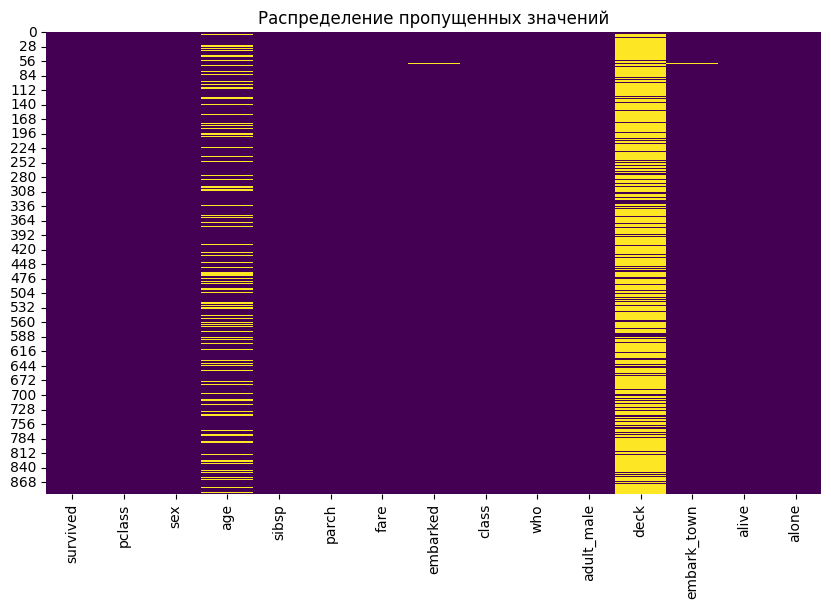

In [34]:
# Визуализация пропущенных данных
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Распределение пропущенных значений")
plt.show()

In [35]:


# Анализ числовых признаков
print("\n" + "="*50)
print("Описательная статистика числовых признаков:")
print(data.describe())



Описательная статистика числовых признаков:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


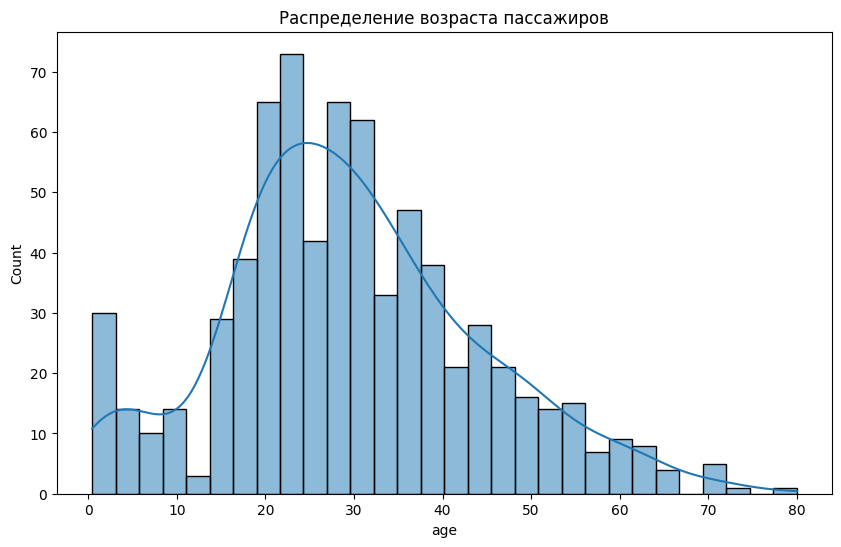

In [36]:

# Визуализация распределения возраста
plt.figure(figsize=(10, 6))
sns.histplot(data['age'].dropna(), kde=True, bins=30)
plt.title("Распределение возраста пассажиров")
plt.show()



Количество выживших и погибших:
survived
0    549
1    342
Name: count, dtype: int64


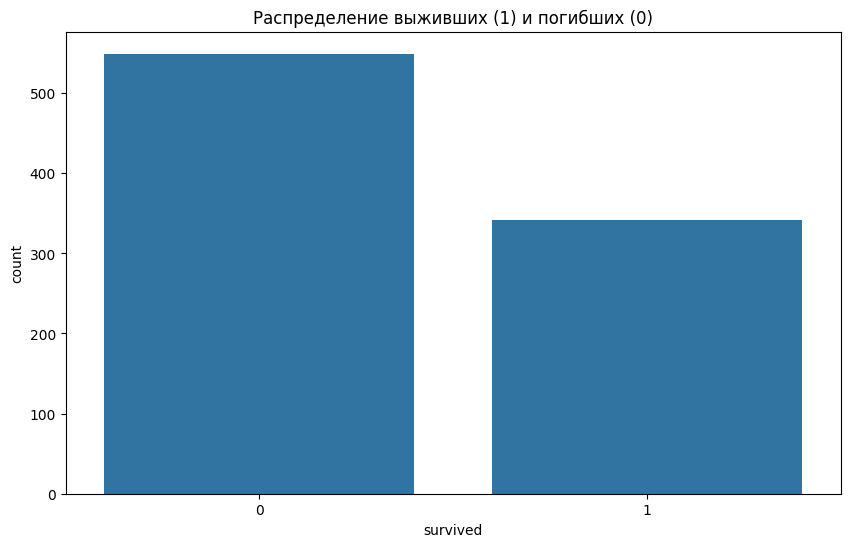

In [37]:

# Анализ выживаемости
print("\n" + "="*50)
print("Количество выживших и погибших:")
print(data['survived'].value_counts())
# Визуализация выживаемости
plt.figure(figsize=(10, 6))
sns.countplot(x='survived', data=data)
plt.title("Распределение выживших (1) и погибших (0)")
plt.show()



In [39]:

# Влияние пола на выживаемость
print("\n" + "="*50)
print("Выживаемость по полу:")
print(data.groupby('sex')['survived'].mean())


Выживаемость по полу:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [41]:

# Очистка данных
data = data.drop(['deck', 'embark_town', 'alive', 'who', 'adult_male', 'class'], axis=1)
data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# Преобразование категориальных признаков
data = pd.get_dummies(data, columns=['sex', 'embarked', 'alone'], drop_first=True)

# Разделение на признаки и целевую переменную
X = data.drop('survived', axis=1)
y = data['survived']

# Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)


In [42]:

# 3. Логистическая регрессия
C_values = np.arange(1, 11)
logistic_accuracy = []
logistic_precision = []
logistic_recall = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    logistic_accuracy.append(accuracy_score(y_test, y_pred))
    logistic_precision.append(precision_score(y_test, y_pred))
    logistic_recall.append(recall_score(y_test, y_pred))


In [43]:

# 4. SVM с RBF ядром
svm_accuracy = []
svm_precision = []
svm_recall = []

for C in C_values:
    model = SVC(kernel='rbf', C=C)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    svm_accuracy.append(accuracy_score(y_test, y_pred))
    svm_precision.append(precision_score(y_test, y_pred))
    svm_recall.append(recall_score(y_test, y_pred))


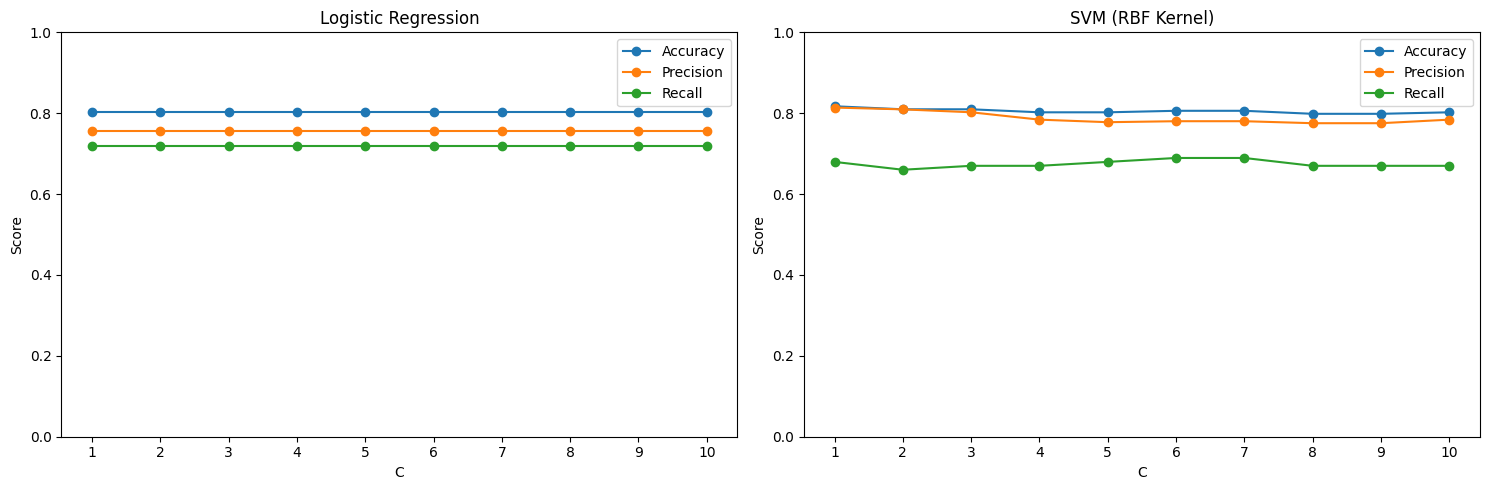

In [44]:

# 6. Построение графиков
plt.figure(figsize=(15, 5))

# Графики для логистической регрессии
plt.subplot(1, 2, 1)
plt.plot(C_values, logistic_accuracy, label='Accuracy', marker='o')
plt.plot(C_values, logistic_precision, label='Precision', marker='o')
plt.plot(C_values, logistic_recall, label='Recall', marker='o')
plt.xlabel('C')
plt.ylabel('Score')
plt.title('Logistic Regression')
plt.legend()
plt.xticks(np.arange(1,11))
plt.ylim(0, 1)

# Графики для SVM
plt.subplot(1, 2, 2)
plt.plot(C_values, svm_accuracy, label='Accuracy', marker='o')
plt.plot(C_values, svm_precision, label='Precision', marker='o')
plt.plot(C_values, svm_recall, label='Recall', marker='o')
plt.xlabel('C')
plt.ylabel('Score')
plt.title('SVM (RBF Kernel)')
plt.legend()
plt.xticks(np.arange(1,11))
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


In [45]:

# 7. Сравнение моделей
print("Логистическая регрессия:")
print(f"Лучшая Accuracy: {max(logistic_accuracy)} при C = {C_values[np.argmax(logistic_accuracy)]}")
print(f"Лучшая Precision: {max(logistic_precision)} при C = {C_values[np.argmax(logistic_precision)]}")
print(f"Лучший Recall: {max(logistic_recall)} при C = {C_values[np.argmax(logistic_recall)]}")

print("\nSVM (RBF):")
print(f"Лучшая Accuracy: {max(svm_accuracy)} при C = {C_values[np.argmax(svm_accuracy)]}")
print(f"Лучшая Precision: {max(svm_precision)} при C = {C_values[np.argmax(svm_precision)]}")
print(f"Лучший Recall: {max(svm_recall)} при C = {C_values[np.argmax(svm_recall)]}")

Логистическая регрессия:
Лучшая Accuracy: 0.8022388059701493 при C = 1
Лучшая Precision: 0.7551020408163265 при C = 1
Лучший Recall: 0.7184466019417476 при C = 1

SVM (RBF):
Лучшая Accuracy: 0.8171641791044776 при C = 1
Лучшая Precision: 0.813953488372093 при C = 1
Лучший Recall: 0.6893203883495146 при C = 6


## Выводы:
- При увеличении C (уменьшении регуляризации) модели могут начать переобучаться.
- SVM с RBF ядром может быть более чувствителен к выбору C, чем логистическая регрессия.
- Оптимальное значение C зависит от задачи: если важна точность (Precision), нужно выбирать одно C, если полнота (Recall) — другое.
- Логистическая регрессия часто более стабильна при разных C, чем SVM.